# 🏷️ Finding Topics in Banking Messages — NLP Clustering and Labelling

## Business question

When you have thousands of unlabeled customer messages and no existing
taxonomy, how do you find the natural groupings and trust that what
you found is real, not just an effect of the method you happened to
pick?

## What's in this notebook

Three different ways of answering that question, run against the same
~13,000 real banking customer service messages (BANKING77), then
checked against the dataset's true intent labels (which the
clustering never sees) to determine which approach actually recovers real
structure:

1. **TF-IDF + KMeans** — the baseline, clustering by shared
   words
2. **Sentence embeddings + KMeans** — same algorithm, but clustering
   by shared *meaning* instead
3. **BERTopic** — lets the number of topics emerge on its own, instead
   of me guessing k upfront

The clusters that come out of this feed into the next step: an LLM
that turns each cluster into a human-readable label and supplies the rationale.

## How this was built

Built working alongside Claude (Anthropic) as a thought partner
throughout, in addition to code. Exampes of analytical decisions: 
how to pick k when there's no "correct" answer, why purity
was the wrong metric to trust once I was comparing methods with
different cluster counts, and the moment I realized the messiest
cluster wasn't a tuning problem at all. The markdown cells throughout
try to preserve that reasoning as it actually happened, not a cleaned-up
version written after the fact.

## Contents

## Table of contents

1. Load the cleaned data 
1. Method A: TF-IDF + KMeans (baseline)
   1. Vectorize with TF-IDF
   1. First clustering attempt (guessed k)
   1. Peek inside a cluster
   1. The elbow method
   1. Silhouette score — a second internal metric
   1. Pick a final k and refit
   1. Validate against the true intents
   1. Save the clustered data
1. Method B: Embeddings + KMeans
   1. Embed the messages
   1. Cluster with KMeans (same k, for a fair comparison)
   1. Validate against true intents
1. Method C: BERTopic
   1. Fit BERTopic
   1. Inspect discovered topics
   1. Validate against true intents
1. Comparing the three methods
1. Saving the clustered data
1. AI auto-labelling
   1. Select representative messages per cluster
   1. Build the labeling prompt and call the Claude API
   1. Parse the response
   1. Run across all clusters and merge labels back
   1. Spot-check the results

In [81]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import normalize
from sklearn.metrics import normalized_mutual_info_score, adjusted_rand_score
from sklearn.cluster import KMeans
from sentence_transformers import SentenceTransformer
from sklearn.metrics import silhouette_score
from umap import UMAP
from bertopic import BERTopic
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path
from dotenv import load_dotenv
import anthropic
import json
import os
import re

## 1. Load the cleaned data

This session picks up from the pipeline in `src/data_pull.py` and `src/clean.py`:

- **`data_pull.py`** pulls the **BANKING77** dataset — ~13,000 real banking
  customer service messages, each labeled with one of 77 intents
  (e.g. `card_arrival`, `wrong_amount_of_cash_received`) straight from
  PolyAI-LDN's GitHub repo (Casanueva et al., 2020). No API key needed.
- **`clean.py`** standardizes the raw pull: renames columns to `message` /
  `true_intent`, drops empty or duplicate messages, and assigns a
  `message_id`.

The `true_intent` labels ride along in the cleaned data, but they're held out
here so clustering never sees them. They only resurface in Step 7, to check
how well the groups we find on our own line up with the labels we weren't
allowed to peek at.

In [22]:
df = pd.read_csv("../data/processed/messages_clean.csv")
print(df.shape)
df.head()

(13072, 4)


,message_id,message,true_intent,split
0,0,I am still waiting on my card?,card_arrival,train
1,1,What can I do if my card still hasn't arrived ...,card_arrival,train
2,2,I have been waiting over a week. Is the card s...,card_arrival,train
3,3,Can I track my card while it is in the process...,card_arrival,train
4,4,"How do I know if I will get my card, or if it ...",card_arrival,train


In [23]:
# How many unique true_intents?
print("Actual number of intents:", df["true_intent"].nunique())


Actual number of intents: 77


## 2. Method A: TF-IDF + KMeans (baseline)

### Vectorize with TF-IDF

Turns each message into a row of numbers, one column per word, where the
value is "how distinctive is this word to this message." Two different
things are doing the muting here, worth keeping separate:

- **Stop words** ("the", "is", "and") are dropped - 
  `stop_words="english"` strips them before scoring starts. They
  never get a column.
- Domain-common words like **"account"** aren't stop words, so they do
  get a column but TF-IDF's own math mutes them anyway: a word that
  shows up in a huge share of messages carries less information about
  what makes any *one* message distinctive, so it ends up with a low
  weight rather than being removed outright.

Rare, specific words (a product name, an unusual complaint) get
highlighted. They show up in few messages, so they carry more of that
distinctiveness signal. `X` ends up as a sparse matrix:
(n_messages x n_words).

In [62]:
vectorizer = TfidfVectorizer(
    max_features=2000,   # cap vocabulary size -- keeps this fast and manageable
    stop_words="english",  # drop "the", "is", "and", etc.
    min_df=5,             # ignore words that appear in fewer than 5 messages (likely noise)
)
X_tfidf = vectorizer.fit_transform(df["message"])
print(X_tfidf.shape)

(13072, 868)


### First clustering attempt

We're not trying to get k right yet. Just seeing KMeans run and
checking that cluster sizes look at least somewhat reasonable
(not one giant cluster with everything dumped in it).

In [25]:
k = 10
km_tfidf = KMeans(n_clusters=k, random_state=42, n_init=10)
df["cluster"] = km_tfidf.fit_predict(X_tfidf)
print(df["cluster"].value_counts().sort_index())

cluster
0     340
1     614
2     681
3     438
4    5111
5    2615
6     664
7    1059
8    1146
9     404
Name: count, dtype: int64


### Peek inside a cluster

Sanity check: do messages in the same cluster actually look
similar to a human? Change the number below and re-run this cell a
few times to spot-check different clusters.

In [26]:
# Sanity check before formal validation: for each cluster, what are the
# 3 most common true intents, and how much of the cluster do they cover?
# A cluster dominated by one intent (e.g. 90% "card_arrival") suggests
# TF-IDF found a real grouping; one split evenly across many intents
# suggests it's a grab-bag / noise cluster.
for cluster_id in sorted(df["cluster"].unique()):
    subset = df[df["cluster"] == cluster_id]
    top_intents = subset["true_intent"].value_counts().head(3)
    print(f"Cluster {cluster_id:>2} (n={len(subset):>4}): {dict(top_intents)}")

Cluster  0 (n= 340): {'declined_transfer': np.int64(130), 'declined_card_payment': np.int64(93), 'declined_cash_withdrawal': np.int64(55)}
Cluster  1 (n= 614): {'wrong_amount_of_cash_received': np.int64(107), 'balance_not_updated_after_cheque_or_cash_deposit': np.int64(104), 'cash_withdrawal_not_recognised': np.int64(103)}
Cluster  2 (n= 681): {'card_payment_wrong_exchange_rate': np.int64(187), 'wrong_exchange_rate_for_cash_withdrawal': np.int64(145), 'exchange_rate': np.int64(142)}
Cluster  3 (n= 438): {'change_pin': np.int64(156), 'get_physical_card': np.int64(145), 'pin_blocked': np.int64(133)}
Cluster  4 (n=5111): {'request_refund': np.int64(189), 'direct_debit_payment_not_recognised': np.int64(161), 'apple_pay_or_google_pay': np.int64(149)}
Cluster  5 (n=2615): {'activate_my_card': np.int64(191), 'card_arrival': np.int64(187), 'card_linking': np.int64(171)}
Cluster  6 (n= 664): {'card_payment_fee_charged': np.int64(166), 'transfer_fee_charged': np.int64(117), 'extra_charge_on_stat

In [27]:
# one at a time
cluster_to_check = 4
df[df["cluster"] == cluster_to_check]["message"].sample(10, random_state=1).tolist()

['When will my transfer go through?',
 'can i deposit a check here?',
 'my google pay seems to be acting up.',
 'Why did my top-up not go through?',
 'what is the most i can top up?',
 'The ATM only gave me 10 pounds when I withdrew 30. What do I do?',
 'Can you tell me the cost of a transfer?',
 'How long does it take for transfers to process?  I sent funds to a friend, and she says that she has not yet received anything.',
 'I sent you a cheque a few days ago and I noticed that nothing has happened yet. Can you tell me the status of my cheque please?',
 'What can i pay with out  fees']

In [28]:
# one at a time
cluster_to_check = 5
df[df["cluster"] == cluster_to_check]["message"].sample(10, random_state=1).tolist()

["I'd like to apply for a Visa Card.",
 'Is there something wrong with my ATM Card?  Tried using it earlier and it did not work.',
 'What do I need to do to activate my new card?',
 'Please let me know how to place an order for a virtual card',
 "I'm in China and really need a new card.",
 'My card is expiring soon, How do I order a new card?',
 'A strange card payment, I do not recognize it.',
 'What number of transactions can i do with one disposable card?',
 'How do I know if I will get my card, or if it is lost?',
 'What to do if my card is about to expire?']

### The elbow method

For each k, refit KMeans and record inertia (total distance from each
message to its cluster's center, lower is "tighter" clusters).
Watch for where the drop from one k to the next stops being dramatic.

In [40]:
inertias = []
k_range = range(5, 105, 5)
for k in k_range:
    km_tfidf = KMeans(n_clusters=k, random_state=42, n_init=10)
    km_tfidf.fit(X_tfidf)
    inertias.append(km_tfidf.inertia_)
    print(f"k={k:>3}  inertia={km_tfidf.inertia_:.1f}")

k=  5  inertia=12083.8
k= 10  inertia=11624.6
k= 15  inertia=11217.7
k= 20  inertia=10945.0
k= 25  inertia=10665.6
k= 30  inertia=10458.1
k= 35  inertia=10244.5
k= 40  inertia=10056.3
k= 45  inertia=9898.6
k= 50  inertia=9750.9
k= 55  inertia=9505.9
k= 60  inertia=9447.7
k= 65  inertia=9405.9
k= 70  inertia=9229.2
k= 75  inertia=9117.3
k= 80  inertia=9011.0
k= 85  inertia=8899.0
k= 90  inertia=8826.0
k= 95  inertia=8734.9
k=100  inertia=8668.3


In [41]:
ks = list(k_range)
deltas = [inertias[i] - inertias[i+1] for i in range(len(inertias) - 1)]

print(f"{'k step':>10} | {'drop':>8} | note")
for i, d in enumerate(deltas):
    note = ""
    if i > 0:
        pct_change = (d - deltas[i-1]) / deltas[i-1] * 100
        note = f"{pct_change:+.0f}% vs prior drop"
        if d > deltas[i-1] * 1.3:   # drop grew >30% instead of continuing to shrink
            note += "  <-- flag"
    print(f"{ks[i]:>3}->{ks[i+1]:<3} | {d:>8.1f} | {note}")

    k step |     drop | note
  5->10  |    459.2 | 
 10->15  |    406.9 | -11% vs prior drop
 15->20  |    272.6 | -33% vs prior drop
 20->25  |    279.4 | +2% vs prior drop
 25->30  |    207.5 | -26% vs prior drop
 30->35  |    213.5 | +3% vs prior drop
 35->40  |    188.3 | -12% vs prior drop
 40->45  |    157.7 | -16% vs prior drop
 45->50  |    147.7 | -6% vs prior drop
 50->55  |    244.9 | +66% vs prior drop  <-- flag
 55->60  |     58.2 | -76% vs prior drop
 60->65  |     41.8 | -28% vs prior drop
 65->70  |    176.7 | +323% vs prior drop  <-- flag
 70->75  |    111.9 | -37% vs prior drop
 75->80  |    106.3 | -5% vs prior drop
 80->85  |    112.0 | +5% vs prior drop
 85->90  |     73.0 | -35% vs prior drop
 90->95  |     91.1 | +25% vs prior drop
 95->100 |     66.5 | -27% vs prior drop


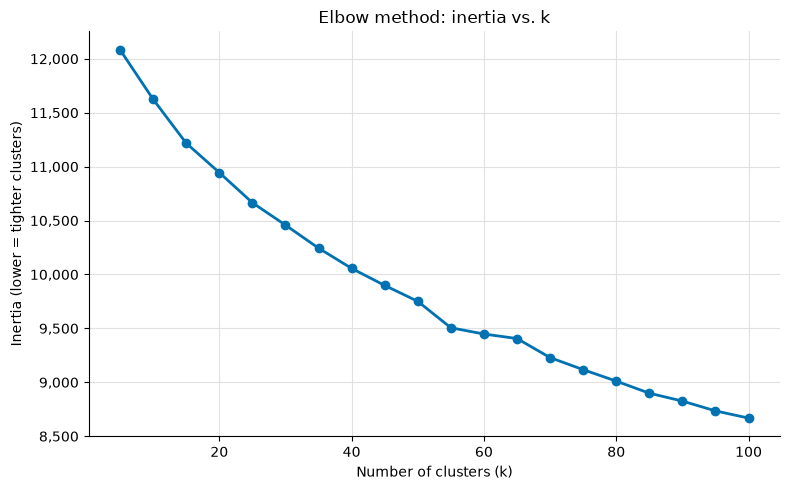

In [42]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(list(k_range), inertias, marker='o', color="#0072B2", linewidth=2, markersize=6)

ax.set_xlabel("Number of clusters (k)")
ax.set_ylabel("Inertia (lower = tighter clusters)")
ax.set_title("Elbow method: inertia vs. k")

# Comma-separated labels: "10,000" instead of "10000"
ax.yaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.0f}"))

ax.grid(True, color="#e0e0e0", linewidth=0.8)   # recessive gridlines, not a box
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

### Silhouette score

In [43]:
sil_scores = []
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_tfidf)
    sil_scores.append(silhouette_score(X_tfidf, labels, sample_size=2000, random_state=42))
    print(f"k={k:>2}  silhouette={sil_scores[-1]:.4f}")

k= 5  silhouette=0.0267
k=10  silhouette=0.0341
k=15  silhouette=0.0472
k=20  silhouette=0.0537
k=25  silhouette=0.0562
k=30  silhouette=0.0599
k=35  silhouette=0.0656
k=40  silhouette=0.0759
k=45  silhouette=0.0793
k=50  silhouette=0.0771
k=55  silhouette=0.0894
k=60  silhouette=0.0766
k=65  silhouette=0.0883
k=70  silhouette=0.0902
k=75  silhouette=0.0973
k=80  silhouette=0.0943
k=85  silhouette=0.1016
k=90  silhouette=0.0988
k=95  silhouette=0.0987
k=100  silhouette=0.0990


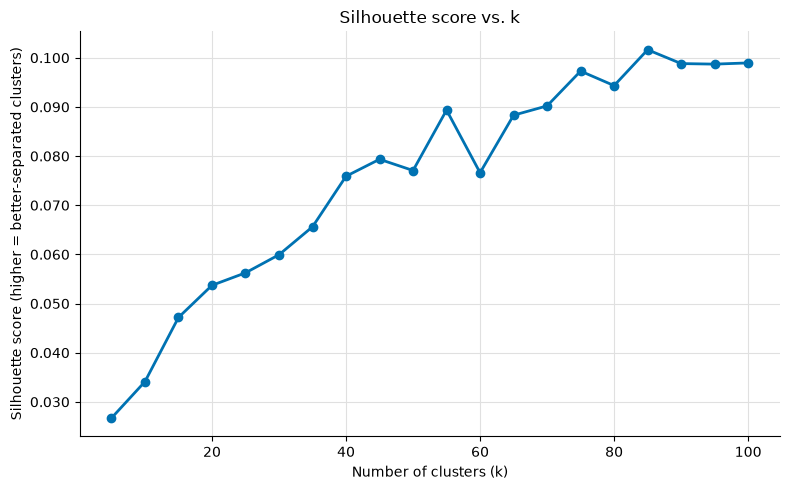

In [44]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(list(k_range), sil_scores, marker='o', color="#0072B2", linewidth=2, markersize=6)

ax.set_xlabel("Number of clusters (k)")
ax.set_ylabel("Silhouette score (higher = better-separated clusters)")
ax.set_title("Silhouette score vs. k")

ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.3f"))  # 3 decimals, not 0

ax.grid(True, color="#e0e0e0", linewidth=0.8)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

### Pick a final k and refit

Normally you'd want to choose a k where the gain, i.e., the drop in inertia, or here, the lift in silhouette score, starts to flatten out, since past that point you're mostly carving up noise rather than finding real additional structure.

In this case, that point isn't a sharp elbow but a plateau: silhouette keeps climbing through about k=85, then flattens out through k=100. Interestingly, that plateau lines up closely with BANKING77's 77 true intents which is a reassuring sign that the clustering is picking up real granularity, not just noise. But 85 clusters isn't a useful number for a human (or an LLM) to label and act on downstream, so I chose a smaller k that trades some of that statistical support for interpretability.

In [46]:

best_idx = np.argmax(sil_scores)
print(f"Peak silhouette: k={list(k_range)[best_idx]}, score={sil_scores[best_idx]:.4f}")

Peak silhouette: k=85, score=0.1016


In [54]:
FINAL_K = 35

km_tfidf = KMeans(n_clusters=FINAL_K, random_state=42, n_init=10)
df["cluster"] = km_tfidf.fit_predict(X_tfidf)
print(df["cluster"].value_counts().sort_index())

cluster
0      284
1      264
2      364
3      181
4      236
5      348
6      308
7     2227
8      107
9     1327
10     837
11     390
12     157
13     257
14     232
15     377
16     275
17     307
18     191
19     260
20     339
21     162
22     464
23     172
24     220
25     295
26     767
27     161
28     126
29     462
30      96
31     214
32     105
33     276
34     284
Name: count, dtype: int64


35 clusters was chosen as a practical middle ground, but the tradeoff is that we have "junk drawer" clusters (purity < 30%).

In [ ]:
crosstab = pd.crosstab(df["cluster"], df["true_intent"])
purity = crosstab.max(axis=1) / crosstab.sum(axis=1)
cluster_sizes = crosstab.sum(axis=1)

summary = pd.DataFrame({"size": cluster_sizes, "purity": purity}).sort_values("purity")
print(summary.head(10))  # your messiest clusters, worst first

junk_drawers = summary[summary["purity"] < 0.3]
print(f"{len(junk_drawers)} of {len(summary)} clusters have no dominant intent (purity < 30%)")

         size    purity
cluster                
7        2227  0.055680
3         181  0.071823
5         348  0.100575
9        1327  0.127355
19        260  0.138462
14        232  0.146552
10        837  0.167264
26        767  0.183833
11        390  0.251282
15        377  0.251989
14 of 35 clusters have no dominant intent (purity < 30%)


### Validate against the true intents

This is the payoff of using BANKING77: we never showed KMeans the real
labels, so we can now check whether it rediscovered real structure.
For each cluster, "purity" = what fraction share the most common true
intent in that cluster. High purity = the cluster is coherent.

In [56]:
labels_tfidf = df["cluster"]

nmi_tfidf = normalized_mutual_info_score(df["true_intent"], labels_tfidf)
ari_tfidf = adjusted_rand_score(df["true_intent"], labels_tfidf)
print(f"TF-IDF + KMeans NMI={nmi_tfidf:.3f} ARI={ari_tfidf:.3f}")

TF-IDF + KMeans NMI=0.503 ARI=0.118


In [57]:
crosstab = pd.crosstab(df["cluster"], df["true_intent"])
purity = crosstab.max(axis=1) / crosstab.sum(axis=1)
print(purity.describe())
print("\nLowest-purity (messiest) clusters:")
print(purity.sort_values().head())

count    35.000000
mean      0.351796
std       0.188970
min       0.055680
25%       0.251636
50%       0.308475
75%       0.467630
max       0.950617
dtype: float64

Lowest-purity (messiest) clusters:
cluster
7     0.055680
3     0.071823
5     0.100575
9     0.127355
19    0.138462
dtype: float64


## 3. Method B: Embeddings + KMeans

### Embed the messages

In [65]:
model = SentenceTransformer("all-MiniLM-L6-v2")
embeddings = model.encode(df["message"].tolist(), show_progress_bar=True, batch_size=64)


Batches: 100%|██████████| 205/205 [00:05<00:00, 40.67it/s]


### Cluster with KMeans

In [69]:
embeddings_normed = normalize(embeddings)

km_embed = KMeans(n_clusters=35, random_state=42, n_init=10)
labels_embed = km_embed.fit_predict(embeddings)

### Validate under true intents

In [70]:
nmi_embed = normalized_mutual_info_score(df["true_intent"], labels_embed)
ari_embed = adjusted_rand_score(df["true_intent"], labels_embed)
print(f"Embeddings + KMeans   NMI={nmi_embed:.3f}  ARI={ari_embed:.3f}")

Embeddings + KMeans   NMI=0.711  ARI=0.359


## 4. Method C: BERTopic

Reuses the embeddings from Method B rather than downloading a second model - keep things efficient and keeps both methods in the same embedding space (which is a fairer comparison anyway).

### Fit BERTopic

In [ ]:
# customized n_jobs=1, low_memory=True to fit on 16GB of local RAM
umap_model = UMAP(n_jobs=1, low_memory=True)
topic_model = BERTopic(embedding_model=None, calculate_probabilities=False, verbose=True, umap_model=umap_model)
topics, _ = topic_model.fit_transform(df["message"].tolist(), embeddings=embeddings)

2026-09-24 12:50:20,034 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-09-24 12:50:25,917 - BERTopic - Dimensionality - Completed ✓
2026-09-24 12:50:25,918 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-09-24 12:50:26,053 - BERTopic - Cluster - Completed ✓
2026-09-24 12:50:26,056 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-09-24 12:50:26,193 - BERTopic - Representation - Completed ✓


### Inspect discovered topics

In [72]:
# Raw topic count before merging (from the original fit when no k was specified)
n_topics_raw = len(set(topics)) - (1 if -1 in topics else 0)

# Let BERTopic merge highly similar micro-topics automatically
topic_model.reduce_topics(df["message"].tolist(), nr_topics="auto")

auto_topics = topic_model.topics_
is_outlier_auto = pd.Series(auto_topics) == -1
n_auto_topics = len(set(auto_topics)) - 1
outlier_pct_auto = is_outlier_auto.mean()

print(f"BERTopic found {n_topics_raw} raw micro-topics with no k specified at all;")
print(f"auto-merging consolidated that to {n_auto_topics} topics.")
print(f"{outlier_pct_auto:.1%} of messages landed in the outlier bucket.")


2026-09-24 12:56:31,224 - BERTopic - Topic reduction - Reducing number of topics
2026-09-24 12:56:31,324 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-09-24 12:56:31,422 - BERTopic - Representation - Completed ✓
2026-09-24 12:56:31,424 - BERTopic - Topic reduction - Reduced number of topics from 343 to 182


BERTopic found 342 raw micro-topics with no k specified at all;
auto-merging consolidated that to 181 topics.
12.7% of messages landed in the outlier bucket.


# Validate against true intents

In [73]:
nmi_bertopic = normalized_mutual_info_score(
    df["true_intent"][~is_outlier_auto], pd.Series(auto_topics)[~is_outlier_auto]
)
ari_bertopic = adjusted_rand_score(
    df["true_intent"][~is_outlier_auto], pd.Series(auto_topics)[~is_outlier_auto]
)
print(f"BERTopic (auto-reduced)   NMI={nmi_bertopic:.3f}  ARI={ari_bertopic:.3f}")

# Which true intents got scattered across multiple discovered topics?
# (the mirror image of Method A's junk-drawer clusters: instead of one
# cluster mixing many intents, one intent split across several topics)
matched = pd.DataFrame({
    "true_intent": df["true_intent"][~is_outlier_auto],
    "topic": pd.Series(auto_topics)[~is_outlier_auto],
})
topics_per_intent = matched.groupby("true_intent")["topic"].nunique().sort_values(ascending=False)
print("True intents split across the most distinct topics:")
print(topics_per_intent.head(10))

BERTopic (auto-reduced)   NMI=0.817  ARI=0.469
True intents split across the most distinct topics:
true_intent
direct_debit_payment_not_recognised    17
extra_charge_on_statement              14
compromised_card                       13
card_payment_not_recognised            13
top_up_by_card_charge                  12
top_up_failed                          12
topping_up_by_card                     12
transfer_not_received_by_recipient     12
supported_cards_and_currencies         11
card_payment_fee_charged               11
Name: topic, dtype: int64


## 5 – Comparing the three methods

We discovered that by adding context, first through embeddings and then
further through BERTopic, we could improve the quality of the topic
assignments as compared with the true intents. The increasing NMI
scores tell us that each method's groupings share more information
overall with the true intent labels: moving from word-overlap
(TF-IDF) to meaning (embeddings) to automatically-discovered topics
(BERTopic), the resulting clusters captured progressively more of the
actual intent structure in the data. 

Recall that ARI measures pairwise correctness while NMI measures
share of information. The increasing ARI tells us: 
it's not just that the groupings are generally more
informative, but that individual messages are actually being paired
up correctly more often. In other words, two messages with the same 
true intent are more likely to land in the same cluster, and two with different
intents are more likely to be kept apart. Seeing both metrics, ARI and NMI,  rise
together also matters: it rules out the possibility that the NMI gain is
just a side effect of BERTopic's higher topic count, since ARI is
penalized by mismatched counts and rose anyway.

Further improvement would include isolating *why* BERTopic wins.
Does the gain come from its richer input
(embeddings) or from its clustering algorithm (HDBSCAN, which, unlike
KMeans, can leave a message unassigned instead of forcing it into a
cluster it doesn't fit). Running HDBSCAN directly on the same
embeddings used in Method B would isolate that variable and show
whether the advantage is about what the model understands about each
message, or how it's allowed to group them.

In [75]:
comparison = pd.DataFrame({
    "method": ["TF-IDF + KMeans", "Embeddings + KMeans", "BERTopic"],
    "NMI": [nmi_tfidf, nmi_embed, nmi_bertopic],
    "ARI": [ari_tfidf, ari_embed, ari_bertopic],
})
comparison

,method,NMI,ARI
0,TF-IDF + KMeans,0.503407,0.118133
1,Embeddings + KMeans,0.711097,0.358614
2,BERTopic,0.816674,0.468548


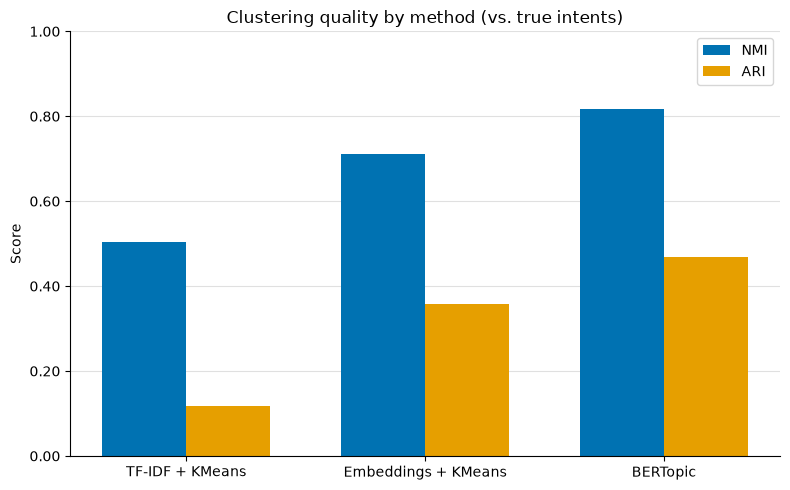

In [77]:
methods = comparison["method"].tolist()
nmi_scores = comparison["NMI"].tolist()
ari_scores = comparison["ARI"].tolist()

x = np.arange(len(methods))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - width/2, nmi_scores, width, label="NMI", color="#0072B2")
ax.bar(x + width/2, ari_scores, width, label="ARI", color="#E69F00")
ax.set_xticks(x)
ax.set_xticklabels(methods)
ax.set_ylabel("Score")
ax.set_ylim(0, 1)
ax.set_title("Clustering quality by method (vs. true intents)")
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.2f"))
ax.grid(True, axis="y", color="#e0e0e0", linewidth=0.8)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend()
ax.set_axisbelow(True)  
plt.tight_layout()
plt.show()

## 6 – Save the clustered data

Of the three methods compared above, BERTopic scored highest on both
NMI and ARI by a wide margin. Given the size of that gap, this is the
assignment that moves forward to labeling — not the fixed k=35 from
TF-IDF+KMeans originally planned. BERTopic's outlier bucket (topic -1,
messages that didn't fit any topic well) is kept in the data rather
than forced into a false group; it's handled explicitly in the
labeling step instead.

In [86]:
df["cluster"] = auto_topics  # BERTopic's auto-reduced topic assignment

df.to_csv("../data/processed/messages_clustered.csv", index=False)

print(f"Saved {len(df)} messages across {n_auto_topics} topics "
      f"(+ {is_outlier_auto.sum()} unclustered) to messages_clustered.csv")

Saved 13072 messages across 181 topics (+ 1657 unclustered) to messages_clustered.csv


## 7 – AI auto-labelling

### Select representative messages per cluster

In [79]:
load_dotenv(Path("../.env"))

client = anthropic.Anthropic()  # reads ANTHROPIC_API_KEY automatically

In [87]:
df = pd.read_csv("../data/processed/messages_clustered.csv")

def get_representative_messages(cluster_id):
    return topic_model.get_representative_docs(cluster_id)

In [88]:
get_representative_messages(0)

['Why is my ATM withdrawal still pending?',
 'Why is my cash withdrawal pending?',
 'Why is my ATM cash withdrawal showing up as a pending transaction?']

### Build the labeling prompt and call the Claude API

In [93]:
def build_prompt(messages):
    numbered = "\n".join(f"{i+1}. {m}" for i, m in enumerate(messages))
    return f"""Below are banking customer service messages that an unsupervised \
clustering algorithm grouped together based on similarity. These are the \
messages closest to the cluster's center -- the most representative examples.

Messages:
{numbered}

Respond with ONLY a JSON object, no other text, in this exact format:
{{"label": "a short 2-4 word label for this cluster", "rationale": "one sentence explaining what unifies these messages"}}"""


### Parse the response

In [ ]:
def extract_json(text):
    text = text.strip()
    if text.startswith("```"):
        text = text.split("\n", 1)[1] if "\n" in text else text
        if text.endswith("```"):
            text = text[:-3]
        text = text.strip()
    try:
        return json.loads(text)
    except json.JSONDecodeError:
        match = re.search(r"\{.*\}", text, re.DOTALL)
        if match:
            return json.loads(match.group())
        raise ValueError(f"Couldn't parse JSON from response:\n{text}")

def label_cluster(cluster_id):
    messages = get_representative_messages(cluster_id)
    response = client.messages.create(
        model="claude-haiku-4-5-20251001",
        max_tokens=200,
        messages=[{"role": "user", "content": build_prompt(messages)}],
    )
    return extract_json(response.content[0].text)

In [90]:
# check one to start (cheaper)
label_cluster(0)

{'label': 'Pending ATM Withdrawal',
 'rationale': 'All messages inquire about the status of cash withdrawals from ATMs that are showing as pending transactions.'}

### Run across all clusters and merge labels back

In [92]:
topic_ids = sorted(set(topic_model.topics_) - {-1})  # skip the outlier bucket

results = {}
failed = []
for topic_id in topic_ids:
    try:
        results[topic_id] = label_cluster(topic_id)
        print(topic_id, results[topic_id])
    except Exception as e:
        print(f"Topic {topic_id} failed: {e}")
        failed.append(topic_id)

if failed:
    print(f"\n{len(failed)} topic(s) failed to label: {failed}")

labels_df = pd.DataFrame(results).T.reset_index().rename(columns={"index": "cluster"})
labels_df.columns = ["cluster", "ai_label", "ai_rationale"]

df = df.merge(labels_df, on="cluster", how="left")
df["ai_label"] = df["ai_label"].fillna("Unclustered / Miscellaneous")
df["ai_rationale"] = df["ai_rationale"].fillna("Messages that didn't fit clearly into any discovered topic.")

df.to_csv("../data/processed/messages_labeled.csv", index=False)
print(f"Saved {len(df)} labeled messages across {len(labels_df)} topics.")

0 {'label': 'Pending ATM Withdrawal', 'rationale': 'All messages inquire about the status of cash withdrawals from ATMs that are showing as pending transactions.'}
1 {'label': 'Currency Exchange Inquiry', 'rationale': 'All messages ask about the process or ability to exchange currencies at the bank.'}
2 {'label': 'Card Exchange Rate Issues', 'rationale': 'All messages concern problems or questions about exchange rates applied to card transactions.'}
3 {'label': 'Card Delivery Timeline', 'rationale': 'All messages ask about the expected arrival time or duration for a new card order.'}
4 {'label': 'Top-up Issues', 'rationale': 'All messages address problems or failures with the account top-up process.'}
5 {'label': 'Transfer Status Inquiry', 'rationale': 'All three messages describe customers requesting assistance to investigate the status of pending transfers that have not yet appeared in their accounts.'}
6 {'label': 'Identity Verification', 'rationale': 'All messages center on the top

### Spot check the results

In [95]:
outlier_pct = (df["cluster"] == -1).mean()
print(f"{outlier_pct:.1%} of messages are unclustered.")

topic_labels = df[["cluster", "ai_label"]].drop_duplicates(subset="cluster")
topic_labels = topic_labels[topic_labels["cluster"] != -1]

dupes = topic_labels[topic_labels.duplicated("ai_label", keep=False)].sort_values("ai_label")
print(f"\n{dupes['ai_label'].nunique()} label(s) reused across {len(dupes)} different topics:")
print(dupes)

12.7% of messages are unclustered.

3 label(s) reused across 6 different topics:
      cluster                 ai_label
1248       27      Card Decline Issues
5544      173      Card Decline Issues
1186      142       Top-up Fee Inquiry
1830       83       Top-up Fee Inquiry
1474      125  Unauthorized Card Usage
1527       53  Unauthorized Card Usage
